In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score

In [2]:
#Loading the dataset
df = pd.read_csv('medical_clean_D209_II.csv')

In [442]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [443]:
#Remove irrelevant columns
df.drop(columns=['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'Lat', 'Lng', 'TimeZone','Job','Item1', 'Item2','Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8'], inplace=True)

In [444]:
#Checking for duplicate values
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [445]:
#Checking for missing values
print(df.isnull().sum())

City                  0
State                 0
County                0
Zip                   0
Population            0
Area                  0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charges    0
dtype: int64


In [446]:
#Encode categorical variables using LabelEncoder
label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   City                10000 non-null  int32  
 1   State               10000 non-null  int32  
 2   County              10000 non-null  int32  
 3   Zip                 10000 non-null  int64  
 4   Population          10000 non-null  int64  
 5   Area                10000 non-null  int32  
 6   Children            10000 non-null  int64  
 7   Age                 10000 non-null  int64  
 8   Income              10000 non-null  float64
 9   Marital             10000 non-null  int32  
 10  Gender              10000 non-null  int32  
 11  ReAdmis             10000 non-null  int32  
 12  VitD_levels         10000 non-null  float64
 13  Doc_visits          10000 non-null  int64  
 14  Full_meals_eaten    10000 non-null  int64  
 15  vitD_supp           10000 non-null  int64  
 16  Soft_

In [448]:
#Identify outliers based on Z-scores
z_scores = np.abs(zscore(df))
z_score_outliers = (z_scores > 3).sum(axis=0)
print("Outliers based on Z-score method:")
print(z_score_outliers)

Outliers based on Z-score method:
City                    0
State                   0
County                  0
Zip                     0
Population            218
Area                    0
Children              202
Age                     0
Income                143
Marital                 0
Gender                  0
ReAdmis                 0
VitD_levels            24
Doc_visits              8
Full_meals_eaten       33
vitD_supp              70
Soft_drink              0
Initial_admin           0
HighBlood               0
Stroke                  0
Complication_risk       0
Overweight              0
Arthritis               0
Diabetes                0
Hyperlipidemia          0
BackPain                0
Anxiety                 0
Allergic_rhinitis       0
Reflux_esophagitis      0
Asthma                  0
Services                0
Initial_days            0
TotalCharge             0
Additional_charges      0
dtype: int64


<Axes: xlabel='Population'>

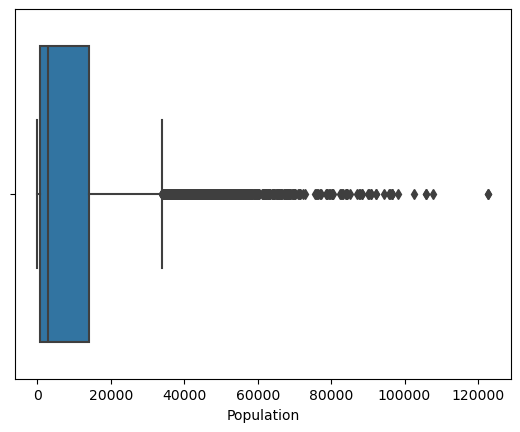

In [449]:
#Checking for outliers for Population
sns.boxplot(x = 'Population', data = df)

<Axes: xlabel='Children'>

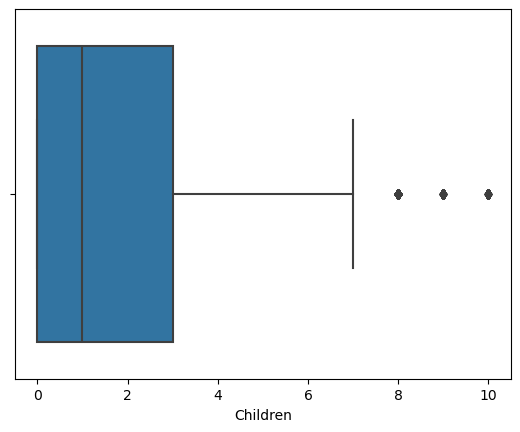

In [450]:
#Checking for outliers for Children
sns.boxplot(x = 'Children', data = df)

<Axes: xlabel='Income'>

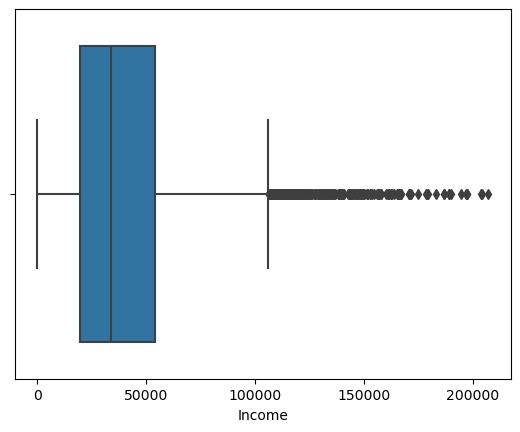

In [451]:
#Checking for outliers for Income
sns.boxplot(x = 'Income', data = df)

<Axes: xlabel='VitD_levels'>

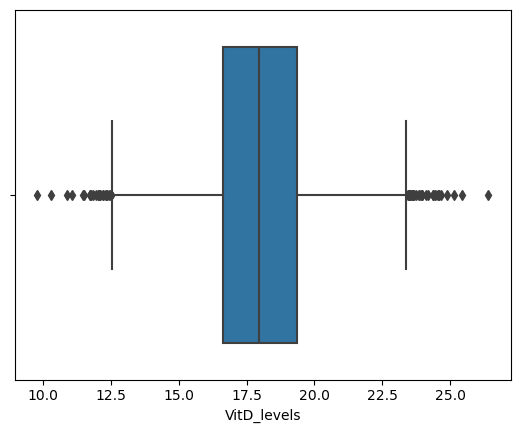

In [452]:
#Checking for outliers for VitD_levels
sns.boxplot(x = 'VitD_levels', data = df)

<Axes: xlabel='Doc_visits'>

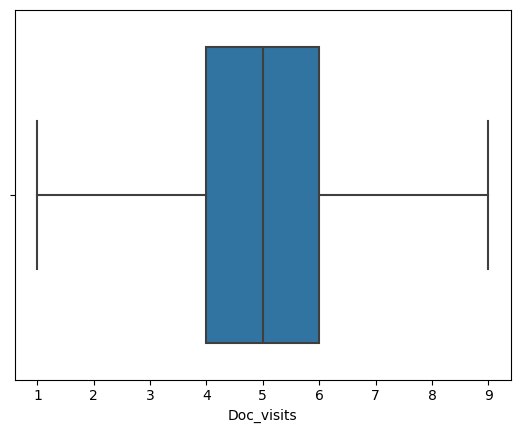

In [453]:
#Checking for outliers for Doc_visits
sns.boxplot(x = 'Doc_visits', data = df)

<Axes: xlabel='Full_meals_eaten'>

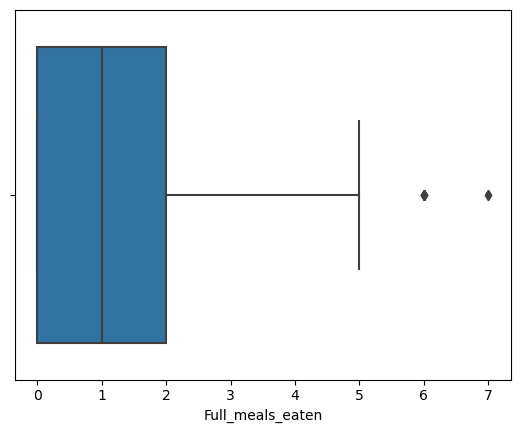

In [454]:
#Checking for outliers for Full meals eaten
sns.boxplot(x = 'Full_meals_eaten', data = df)

<Axes: xlabel='vitD_supp'>

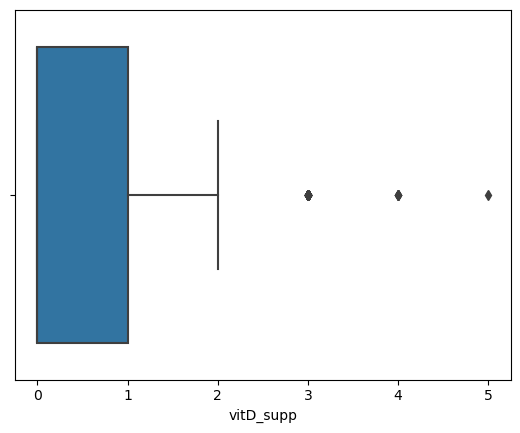

In [455]:
#Checking for outliers for Vitamin D supplement
sns.boxplot(x = 'vitD_supp', data = df)

In [456]:
#Feature scaling for numerical columns, excluding the target variable 'TotalCharge'
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.difference(['TotalCharge'])
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [457]:
#Split the Data into Features (X) and Target (y)
X = df.drop(columns=['TotalCharge'])
y = df['TotalCharge']

In [458]:
#Split the Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [459]:
#Save training and testing data to CSV files
X_train.to_csv("X_train_task2.csv", index=False)
X_test.to_csv("X_test_task2.csv", index=False)
y_train.to_csv("y_train_task2.csv", index=False)
y_test.to_csv("y_test_task2.csv", index=False)

In [460]:
#Load the saved files to check if they were saved correctly
X_train_loaded = pd.read_csv("X_train_task2.csv")
X_test_loaded = pd.read_csv("X_test_task2.csv")
y_train_loaded = pd.read_csv("y_train_task2.csv")
y_test_loaded = pd.read_csv("y_test_task2.csv")

In [461]:
#Initialize the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [462]:
#Fit the Random Forest Regressor
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [463]:
#Make predictions on the test set
y_pred = rf.predict(X_test)

In [464]:
#Evaluate the model
mse = MSE(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 8971.225425607698
R^2 Score: 0.9981269836015685


Initial_days          0.974684
Initial_admin         0.012702
Complication_risk     0.007417
ReAdmis               0.002732
HighBlood             0.000292
Additional_charges    0.000214
Hyperlipidemia        0.000149
City                  0.000127
BackPain              0.000126
Zip                   0.000125
dtype: float64


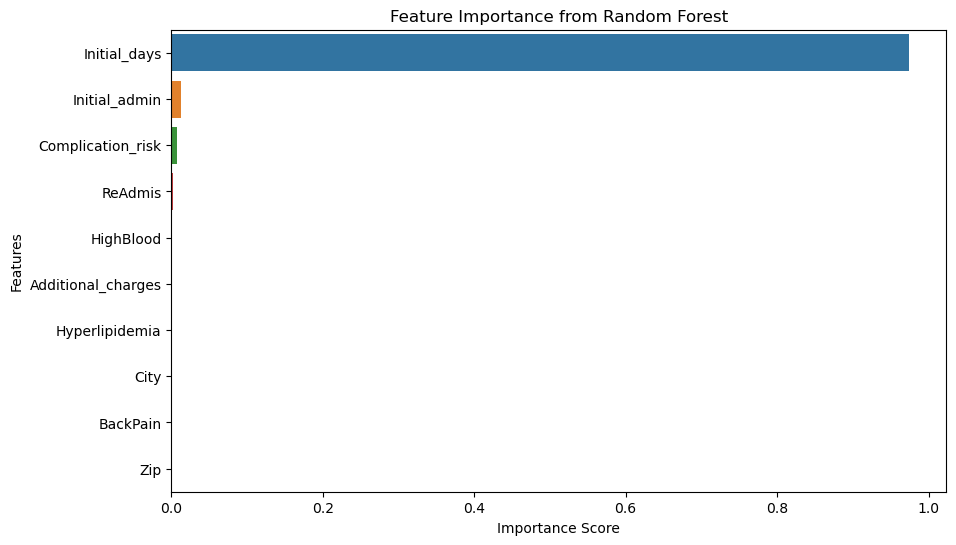

In [465]:
#Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
print(feature_importances)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [466]:
#Save cleaned dataset
new_data_path = 'output/new_medical_data_D209_II.csv'
df.to_csv(new_data_path, index=False)